### Purpose:
Fixed the sampling of the longitude points for finding the peak latitude array; now projecting them up along with projecting the entire aurora. Also fixed the bounding box, which is also projected up. This should give an improved interpolation / correlation matrix.

TODO:
- Now I am projecting both the latitude and longitude slices up as I am projecting the entire aurora up to higher altitudes. However this fucks up the calculation SSD, because I am directly comparing the arrays of latitudes where the brightness is peak, but this assumes that the latitudes at each index corresponds to a particular longitude, which used to be sampled at regular 0.5 lon intervals (obviously this is different now since the longitudes are being projected up as well. 
- Run the code for the 10 UTC event

### Imports

In [1]:
import altitude_helper
import skymap_data_helper

import importlib
importlib.reload(altitude_helper)
from altitude_helper import *

# for interpolation
from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image
from scipy.stats import pearsonr # correlation

import os # folder stuff 

import threading
import time 

from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from functools import partial
from tqdm.notebook import tqdm # since in jupyter

from matplotlib.path import Path # for polygon bounding box 

### Loading Data

In [2]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


/home/molidae/Desktop/berkeley/STEVE2.0/skymap_data_helper.py:273: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["valid_end"] = df["valid_end"].fillna(pd.to_datetime(datetime.utcnow().date()))  # today at midnight UTC


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


### Setup 

In [3]:
# needed yknf and fsmi arrs: lat, long, elevation, azimuth, yknf110 & fsmi110 mask to restrict plots
lat_cam_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_cam_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

lat_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]

#og_h = 150000 CHANGE TO 130KM
og_h = 130000
new_h = 200000
time_index = 251
yknf_lat_proj, yknf_lon_proj = new_spherical_project_lat_lon(full_azimuth_yknf, full_elevation_yknf, lat_cam_yknf, lon_cam_yknf, new_h)
fsmi_lat_proj, fsmi_lon_proj = new_spherical_project_lat_lon(full_azimuth_fsmi, full_elevation_fsmi, lat_cam_fsmi, lon_cam_fsmi, new_h)

rgb_yknf, rgb_fsmi = mod_plot_lat_lon(yknf_rgb_asi_ds, fsmi_rgb_asi_ds, time_index, "Yellowknife", "Fort Smith", yknf_lat_proj, yknf_lon_proj, fsmi_lat_proj, fsmi_lon_proj, new_h)

# limiting interpolation locations (common region between fort smith and yknf
lat_min = min(np.nanmin(yknf_lat_proj), np.nanmin(fsmi_lat_proj))
lon_min = min(np.nanmin(yknf_lon_proj), np.nanmin(fsmi_lon_proj))
lat_max = max(np.nanmax(yknf_lat_proj), np.nanmax(fsmi_lat_proj))
lon_max = max(np.nanmax(yknf_lon_proj), np.nanmax(fsmi_lon_proj))

# common bounding box between yknf and fsmi (based on 150km projection)
# lat_min_box = 60.5
# lat_max_box = 66
# lon_min_box = 240
# lon_max_box = 260

# common bounding box bw yknf and fsmi (based on 130km projection)
lat_min_box, lat_max_box = 60.5, 66
lon_min_box, lon_max_box = 242, 257

# reference longitude grid to use for the rest of the altitude projections --> change to 130km baseline
H_REF = 130000
yknf_lat_ref, yknf_lon_ref = new_spherical_project_lat_lon(
    full_azimuth_yknf, full_elevation_yknf,
    lat_cam_yknf, lon_cam_yknf,
    H_REF
)

fsmi_lat_ref, fsmi_lon_ref = new_spherical_project_lat_lon(
    full_azimuth_fsmi, full_elevation_fsmi,
    lat_cam_fsmi, lon_cam_fsmi,
    H_REF
)

# for initial lon slices at 130km baseline
lon_step = 1.0  # degrees
lat_step = 0.5

GLOBAL_LON_MIN = int(np.floor(
    min(np.nanmin(yknf_lon_ref), np.nanmin(fsmi_lon_ref))
))

GLOBAL_LON_MAX = int(np.ceil(
    max(np.nanmax(yknf_lon_ref), np.nanmax(fsmi_lon_ref))
))

# array of longitudes to to slice at and get the max intensity 
GLOBAL_LON_ARR = np.arange( 
    GLOBAL_LON_MIN,
    GLOBAL_LON_MAX + lon_step,
    lon_step
)

GLOBAL_LAT_MIN = int(np.floor(
    min(np.nanmin(yknf_lat_ref), np.nanmin(fsmi_lat_ref))
))

GLOBAL_LAT_MAX = int(np.ceil(
    max(np.nanmax(yknf_lat_ref), np.nanmax(fsmi_lat_ref))
))

# array of corresp. latitudes to slice at and get the max intensity 
GLOBAL_LAT_ARR = np.arange(
    GLOBAL_LAT_MIN,
    GLOBAL_LAT_MAX + lat_step,
    lat_step
)


# looping through different times and altitudes 
h_arr = [130000, 140000, 150000, 160000, 170000, 180000, 190000, 200000, 210000, 220000, 230000, 240000, 250000, 260000, 270000, 280000, 290000, 300000]
t_arr = [180, 190, 200, 210, 220, 230, 240, 250, 260, 270] # 100 --> 270


In [4]:
GLOBAL_LON_ARR

GLOBAL_LAT_ARR
new_h = 150000

_, peak_lat = fixed_line_interpolate(yknf_lat_proj, yknf_lon_proj, rgb_yknf, 
                                     lat_min_box, lat_max_box, 
                                     lon_min_box, lon_max_box,
                                     lat_cam_yknf, lon_cam_yknf,
                                     "YKNF", time_index, 
                                     og_h, new_h,
                                     GLOBAL_LON_ARR, GLOBAL_LAT_ARR)
# _, peak_lat = altitude_helper.fixed_line_interpolate(fsmi_lat_proj, fsmi_lon_proj, rgb_fsmi, 
#                                      lat_min_box, lat_max_box, 
#                                      lon_min_box, lon_max_box,
#                                      lat_cam_fsmi, lon_cam_fsmi,
#                                      "FSMI", time_index, 
#                                      og_h, new_h,
#                                      GLOBAL_LON_ARR, GLOBAL_LAT_ARR)


=====150.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate



In [5]:
# should be as many elements as there are columns inside the plot above the resampling inside the bounding box 
peak_lat

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan])

In [14]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
from tqdm import tqdm

ssd_correlation_dict = {}
sad_correlation_dict = {}
avg_correlation_dict = {}
med_correlation_dict = {}
diff_dict = {}

#max_workers = max(1, os.cpu_count() - 4)
max_workers = 4

with ProcessPoolExecutor(max_workers=max_workers) as ex:
    futures = [
        ex.submit(
            altitude_helper.new_compute_metrics_for_altitude,
            og_h, new_h,
            t_arr,
            full_azimuth_yknf, full_elevation_yknf, lat_cam_yknf, lon_cam_yknf,
            full_azimuth_fsmi, full_elevation_fsmi, lat_cam_fsmi, lon_cam_fsmi,
            yknf_rgb_asi_ds, fsmi_rgb_asi_ds,
            GLOBAL_LON_ARR, GLOBAL_LAT_ARR
        )
        for new_h in h_arr
    ]

    for f in tqdm(as_completed(futures), total=len(futures), desc="Computing SSD grid"):
        new_h, ssd_vals, sad_vals, avg_diffs, med_diffs, diffs = f.result()
        ssd_correlation_dict[new_h] = ssd_vals
        sad_correlation_dict[new_h] = sad_vals
        avg_correlation_dict[new_h] = avg_diffs
        med_correlation_dict[new_h] = med_diffs
        diff_dict[new_h] = diffs

Computing SSD grid: 100%|████████████████████| 18/18 [1:43:12<00:00, 344.04s/it]


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION

### SSD Matrix

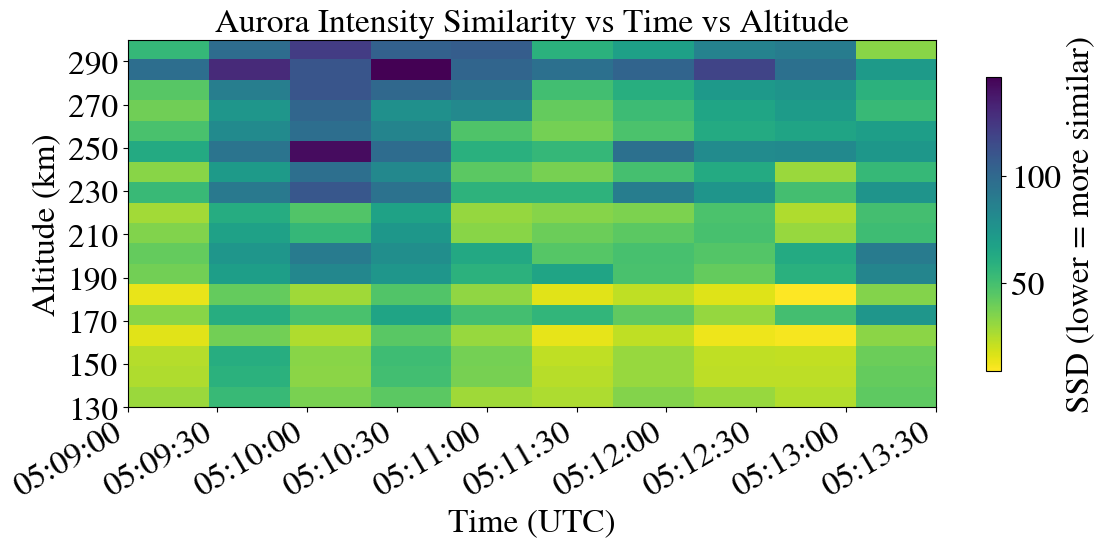

In [15]:
ssd_matrix = np.vstack([ssd_correlation_dict[h] for h in h_arr])

# # prepare altitude + time arrays
# altitude_arr = list(ssd_correlation_dict.keys())
# example_alt = altitude_arr[0]
# #time_arr = np.arange(len(correlation_dict[example_alt]))  # assume same length

# # computer number of altitudes and number of times from ssd_matrix
n_alts, n_times = ssd_matrix.shape

# # generate the time labels for the plot 
t_str_arr = []
for time in t_arr:
    raw_time = yknf_rgb_asi_ds.times.values[time]
    time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
    t_str_arr.append(time_obj.strftime("%H:%M:%S"))

# # plot the correlation matrix over time and projected altitude 
# fig, ax = plt.subplots(figsize=(12, 5))

# im = ax.imshow(
#     ssd_matrix,
#     origin='lower',
#     aspect='auto',
#     extent=[0, n_times - 1, altitude_arr[0], altitude_arr[-1]],
#     cmap='viridis_r'
# )

# cbar = fig.colorbar(im, ax=ax, shrink=0.8)
# cbar.set_label('SSD (lower = more similar)')

# ax.set_xticks(np.arange(n_times))
# ax.set_xticklabels(t_str_arr, rotation=30, ha='right')
# ax.set_ylabel('Altitude (km)')
# ax.set_title('Aurora intensity similarity vs Time vs Altitude')

# plt.tight_layout()
# plt.show()

ssd_matrix = np.vstack([ssd_correlation_dict[h] for h in h_arr])
# 1. Convert your meter-based array to km for cleaner labeling
h_arr_km = [h / 1000 for h in h_arr]

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(
    ssd_matrix,
    origin='lower',
    aspect='auto',
    # Ensure extent matches the km values
    extent=[0, n_times - 1, h_arr_km[0], h_arr_km[-1]], 
    cmap='viridis_r'
)

# --- GRANULAR ALTITUDE LABELS (Every 20km) ---
# Create ticks starting from 150 up to 300, jumping by 20
y_ticks = np.arange(h_arr_km[0], h_arr_km[-1] + 1, 20)
ax.set_yticks(y_ticks)
# ---------------------------------------------

# --- CLEAN TIME LABELS (Subsampling) ---
# Only show ~10-12 time labels to avoid the "black junk" on the X-axis
n_label_step = max(1, n_times // 10) 
indices = np.arange(0, n_times, n_label_step)
selected_labels = [t_str_arr[i] for i in indices]

ax.set_xticks(indices)
ax.set_xticklabels(selected_labels, rotation=30, ha='right')

# Labels and formatting
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('SSD (lower = more similar)')
ax.set_ylabel('Altitude (km)')
ax.set_xlabel('Time (UTC)')
ax.set_title('Aurora Intensity Similarity vs Time vs Altitude')

plt.tight_layout()
plt.show()
